# 07 - Interpretation

Feature importances/coefficients for the memory-decline models, worked
projection examples for synthetic subjects with varying amounts of history,
and - if any real CLI sessions exist - an end-to-end personalized projection
for one real participant. Illustrative only, not diagnostic.

In [1]:
import sys
sys.path.append("..")

import os
import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import load_data, truncate_to_early_visits, validate_longitudinal
from src.longitudinal.slope_extraction import extract_slopes
from src.longitudinal.trends import build_trend_features
from src.models.models import build_feature_matrix, build_gbr_model, build_ridge_model, project_future_score
from src.visualisation.visualisation import plot_feature_importance


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


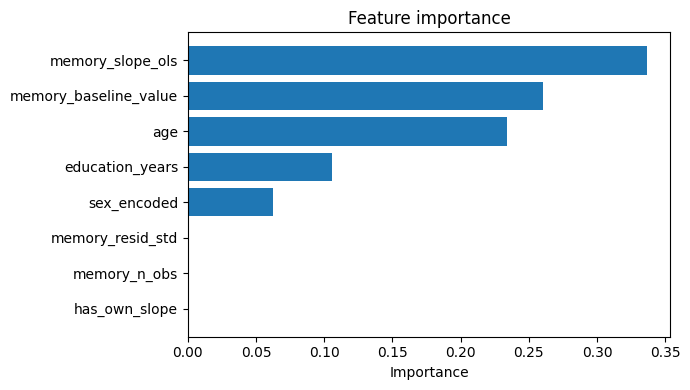

In [2]:
sim_df = validate_longitudinal(load_data("../data/simulated/longitudinal_simulated.csv"))
true_slopes_df = pd.read_csv("../data/simulated/true_slopes.csv", dtype={"participant_id": str})

early_df = truncate_to_early_visits(sim_df, n_visits=2)
early_slope_table = extract_slopes(early_df, domains=("memory",))
early_trend_table = build_trend_features(early_df, domains=("memory",))

X, y, groups = build_feature_matrix(early_slope_table, early_trend_table, true_slopes_df, domain="memory")

gbr = build_gbr_model().fit(X, y)
fig, ax = plt.subplots(figsize=(7, 4))
plot_feature_importance(X.columns, gbr.feature_importances_, ax=ax)
plt.tight_layout()
plt.show()


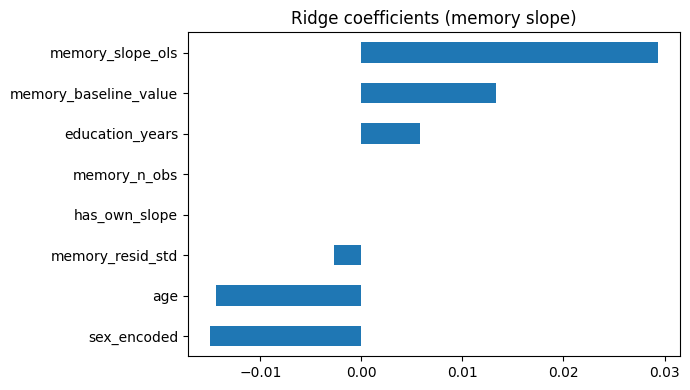

In [3]:
ridge = build_ridge_model().fit(X, y)
pd.Series(ridge.named_steps["ridge"].coef_, index=X.columns).sort_values().plot.barh(
    figsize=(7, 4), title="Ridge coefficients (memory slope)"
)
plt.tight_layout()
plt.show()


In [4]:
# Worked examples: project a few synthetic subjects' scores forward using
# their predicted decline rate, with varying amounts of early history.
predicted_slopes = gbr.predict(X)
examples = pd.DataFrame({
    "participant_id": groups.reset_index(drop=True),
    "n_obs": X["memory_n_obs"].reset_index(drop=True),
    "predicted_slope": predicted_slopes,
}).dropna().sort_values("n_obs").head(5)

current_score = sim_df.loc[sim_df["visit_month"] == sim_df["visit_month"].min(), "memory"].mean()
examples["projected_score_12mo"] = examples["predicted_slope"].apply(
    lambda slope: project_future_score(current_score, slope, months_ahead=12)
)
examples


,participant_id,n_obs,predicted_slope,projected_score_12mo
0,P0000,2,-0.085874,27.066536
1,P0001,2,-0.059189,27.386757
2,P0002,2,-0.083965,27.089443
3,P0003,2,-0.079900,27.138222
4,P0004,2,-0.087120,27.051582


In [5]:
# If real CLI sessions exist (from running `python -m src.play` a few times),
# show one end-to-end personalized projection. Illustrative only - not a
# validated clinical estimate (see docs/limitations.md).
from src.longitudinal.prediction import estimate_personalized_decline

sessions_path = "../data/sessions/sessions_log.csv"
participants_path = "../data/sessions/participants.csv"

if os.path.exists(sessions_path) and os.path.exists(participants_path):
    participants = pd.read_csv(participants_path, dtype={"participant_id": str})
    example_pid = participants["participant_id"].iloc[0]
    example_profile = participants[participants["participant_id"] == example_pid].iloc[0].to_dict()

    estimate = estimate_personalized_decline(
        example_pid, example_profile, sim_path="../data/simulated/longitudinal_simulated.csv",
        sessions_path=sessions_path,
    )
    print(f"Personalized estimate for {example_pid}:")
    print(estimate)
else:
    print("No real CLI sessions recorded yet - run `python -m src.play` a few times to try this.")


No real CLI sessions recorded yet - run `python -m src.play` a few times to try this.
